In [ ]:
import os
import time
import json
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold
from sklearn import clone
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import make_scorer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import warnings

warnings.filterwarnings('ignore')

# Create directory structure
def create_model_directories():
    base_dir = Path('model_training')
    
    # Only create best_models directory
    best_models_dir = base_dir / 'best_models'
    best_models_dir.mkdir(parents=True, exist_ok=True)
    
    return base_dir

base_dir = create_model_directories()

# Check if GPU is available and configure it
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Configure GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

# CV parameters
cv_folds = 10
cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

# Define parameter grids for each model
rf_param_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

xgb_param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.85, 1.0],
    'colsample_bytree': [0.85, 1.0],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.5],
    'reg_lambda': [0.5, 1.0]
}

lgb_param_grid = {
    'n_estimators': [500, 750, 1000],
    'max_depth': [3, 5, 9],
    'learning_rate': [0.01, 0.05],
    'num_leaves': [15, 31, 62],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'min_child_samples': [50, 100]
}

svr_param_grid = {
    'C': [1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.1],  # Kernel coefficient
    'epsilon': [0.001, 0.01, 0.1, 0.2],  # Epsilon in the epsilon-SVR model
    'kernel': ['linear', 'rbf', 'sigmoid'],  # Added 'poly' back for exploration
    'coef0': [0.0, 0.1, 0.5],  # Reduced number of values
    'shrinking': [True, False],  # Explore both shrinking options
    'tol': [1e-3]  # Reduced tolerance values
}

nn_param_grid = {
    'learning_rate': [0.001, 0.0001],
    'batch_size': [32, 64],
    'epochs': [50, 100],
    'layer1_units': [128, 256],
    'layer2_units': [64, 128],
    'layer3_units': [32, 64]
}

# Train and evaluate models with grid search
model_params = {
    'Random Forest': rf_param_grid,
    'XGBoost': xgb_param_grid,
    'LightGBM': lgb_param_grid,
    'SVR': svr_param_grid,
    'Neural Network': nn_param_grid
}

# Load datasets
print("Loading datasets...")
df_original = pd.read_csv('../1_sample_preparation/source/d_clean_remove_small_samples.csv')
df_synthetic = pd.read_csv('../4_response_extraction/synthetic_data_rows_v2.csv')

# Basic information about both datasets
print("\nOriginal Dataset Info:")
print(df_original.info())
print("\nShape:", df_original.shape)
print("\nColumns:", df_original.columns.tolist())

print("\nSynthetic Dataset Info:")
print(df_synthetic.info())
print("\nShape:", df_synthetic.shape)
print("\nColumns:", df_synthetic.columns.tolist())

# Check for missing values
print("\nMissing values in original dataset:")
print(df_original.isnull().sum())
print("\nMissing values in synthetic dataset:")
print(df_synthetic.isnull().sum())

# Basic statistical summary
print("\nOriginal dataset summary:")
print(df_original.describe())
print("\nSynthetic dataset summary:")
print(df_synthetic.describe())

2025-02-21 13:55:21.020357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740117321.084496   42841 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740117321.105243   42841 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-21 13:55:21.262770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Num GPUs Available:  1
GPU memory growth enabled
Loading datasets...

Original Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   target_material   1067 non-null   object 
 1   target_thickness  1067 non-null   float64
 2   pulse_width       1067 non-null   int64  
 3   energy            1067 non-null   float64
 4   spot_size         1067 non-null   float64
 5   intensity         1067 non-null   object 
 6   power             1067 non-null   int64  
 7   cutoff_energy     1067 non-null   float64
dtypes: float64(4), int64(2), object(2)
memory usage: 66.8+ KB
None

Shape: (1067, 8)

Columns: ['target_material', 'target_thickness', 'pulse_width', 'energy', 'spot_size', 'intensity', 'power', 'cutoff_energy']

Synthetic Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total

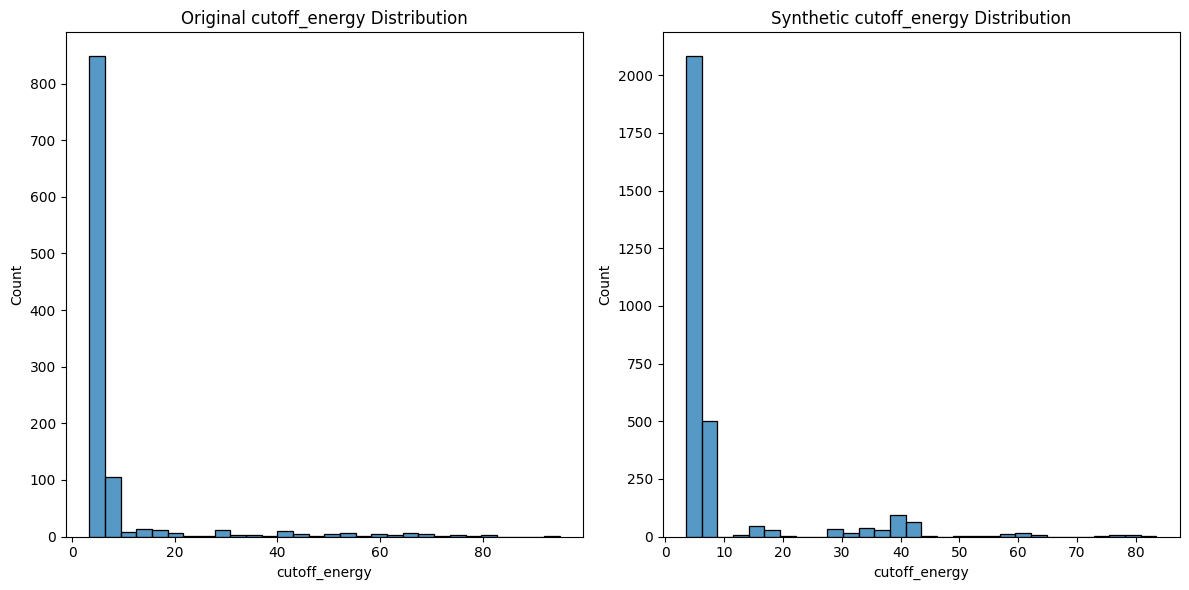

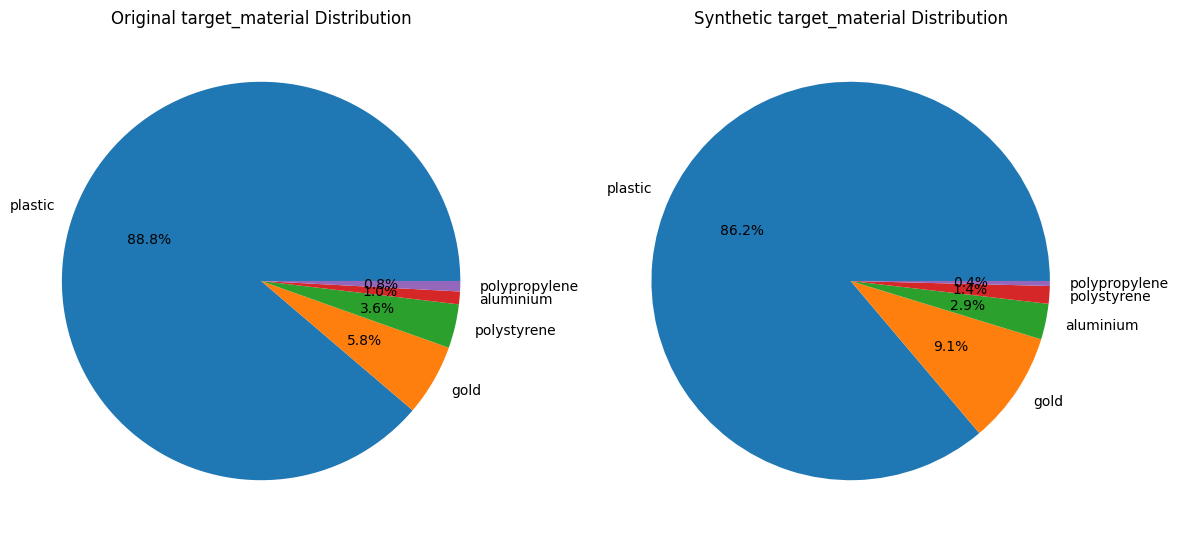

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare numerical distributions between original and synthetic data
def compare_distributions(original_df, synthetic_df, feature):
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(data=original_df, x=feature, bins=30)
    plt.title(f'Original {feature} Distribution')
    
    plt.subplot(1, 2, 2)
    sns.histplot(data=synthetic_df, x=feature, bins=30)
    plt.title(f'Synthetic {feature} Distribution')
    
    plt.tight_layout()
    plt.show()

# Compare categorical distributions
def compare_categorical(original_df, synthetic_df, feature):
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    original_counts = original_df[feature].value_counts()
    plt.pie(original_counts.values, labels=original_counts.index, autopct='%1.1f%%')
    plt.title(f'Original {feature} Distribution')
    
    plt.subplot(1, 2, 2)
    synthetic_counts = synthetic_df[feature].value_counts()
    plt.pie(synthetic_counts.values, labels=synthetic_counts.index, autopct='%1.1f%%')
    plt.title(f'Synthetic {feature} Distribution')
    
    plt.tight_layout()
    plt.show()

# Example usage
compare_distributions(df_original, df_synthetic, 'cutoff_energy')
compare_categorical(df_original, df_synthetic, 'target_material')

In [3]:
# Define features and target
features = ['target_thickness', 'pulse_width', 'energy', 'spot_size', 'intensity', 'power']
target = 'cutoff_energy'

# Function to remove outliers
def remove_outliers(df, feature, lower_percentile, upper_percentile):
    Q1 = df[feature].quantile(lower_percentile)
    Q3 = df[feature].quantile(upper_percentile)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

def preprocess_data(df_original, df_synthetic, features, target):
    if df_original['intensity'].dtype == 'object':
        df_original['intensity'] = df_original['intensity'].astype(float)
    if df_synthetic['intensity'].dtype == 'object':
        df_synthetic['intensity'] = df_synthetic['intensity'].astype(float)
    
    numeric_features = features.copy()
    for nf in numeric_features:
        df_synthetic = remove_outliers(df_synthetic, nf, 0.005, 0.995)
    
    return df_original, df_synthetic

def prepare_data(df_original, df_synthetic, features, target, test_size=0.2):
    X_orig = df_original[features]
    y_orig = df_original[target]
    X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
        X_orig, y_orig, test_size=test_size, random_state=42
    )
    
    X_synth = df_synthetic[features]
    y_synth = df_synthetic[target]
    
    scaler = StandardScaler()
    X_train_orig_scaled = scaler.fit_transform(X_train_orig)
    X_test_orig_scaled = scaler.transform(X_test_orig)
    X_synth_scaled = scaler.transform(X_synth)
    
    X_train_enhanced = np.vstack([X_train_orig_scaled, X_synth_scaled])
    y_train_enhanced = np.concatenate([y_train_orig, y_synth])
    
    return (X_train_orig_scaled, X_test_orig_scaled, y_train_orig, y_test_orig,
            X_train_enhanced, y_train_enhanced)

In [4]:
class KerasRegressor:
    def __init__(self, learning_rate=0.001, batch_size=32, epochs=100, 
                 layer1_units=256, layer2_units=128, layer3_units=64, input_dim=None):
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.layer1_units = layer1_units
        self.layer2_units = layer2_units
        self.layer3_units = layer3_units
        self.input_dim = input_dim
        self.model = None

    def get_params(self, deep=True):
        return {
            'learning_rate': self.learning_rate,
            'batch_size': self.batch_size,
            'epochs': self.epochs,
            'layer1_units': self.layer1_units,
            'layer2_units': self.layer2_units,
            'layer3_units': self.layer3_units,
            'input_dim': self.input_dim
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def create_model(self):
        with tf.device('/GPU:0'):
            model = Sequential([
                Dense(self.layer1_units, activation='relu', input_dim=self.input_dim),
                Dense(self.layer2_units, activation='relu'),
                Dense(self.layer3_units, activation='relu'),
                Dense(1)
            ])
            model.compile(optimizer=Adam(learning_rate=self.learning_rate), 
                        loss='mse',
                        metrics=['mse'])
        return model

    def fit(self, X, y, validation_data=None):
        if self.input_dim is None:
            self.input_dim = X.shape[1]
        
        # Convert inputs to numpy arrays if they aren't already
        X = np.asarray(X)
        y = np.asarray(y)
        
        self.model = self.create_model()
        
        # Create training dataset
        train_dataset = tf.data.Dataset.from_tensor_slices((X, y))\
            .batch(self.batch_size)\
            .prefetch(tf.data.AUTOTUNE)
        
        # Training configuration
        fit_params = {
            'x': train_dataset,
            'epochs': self.epochs,
            'verbose': 0
        }
        
        # Add validation data if provided
        if validation_data is not None:
            X_val, y_val = validation_data
            val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))\
                .batch(self.batch_size)\
                .prefetch(tf.data.AUTOTUNE)
            fit_params['validation_data'] = val_dataset
        
        self.history = self.model.fit(**fit_params)
        return self

    def predict(self, X):
        X = np.asarray(X)
        return self.model.predict(X, batch_size=self.batch_size).flatten()

    def score(self, X, y):
        y_pred = self.predict(X)
        return -np.sqrt(mean_squared_error(y, y_pred))

In [5]:
def save_model_artifacts(model, params, metrics, model_type, version='baseline'):
    """Save only the best model with its parameters and metrics."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_dir_name = model_type.lower().replace(' ', '_')
    save_dir = base_dir / 'best_models'
    model_name = f'{model_dir_name}_{version}'  # Removed '_best_' and timestamp to keep one version
    
    # Create directories if they don't exist
    save_dir.mkdir(parents=True, exist_ok=True)
    
    model_path = save_dir / model_name
    
    # Save model with appropriate extension
    if model_type == 'Neural Network':
        keras_path = str(model_path) + '.keras'
        model.model.save(keras_path)
    else:
        with open(model_path.with_suffix('.pkl'), 'wb') as f:
            pickle.dump(model, f)
    
    # Save configuration and metrics
    config = {
        'parameters': params,
        'metrics': metrics,
        'timestamp': timestamp,
        'version': version
    }
    
    # Save JSON with metrics and parameters
    with open(model_path.with_suffix('.json'), 'w') as f:
        json.dump(config, f, indent=4)
    
    return model_path

def create_training_log():
    return pd.DataFrame(columns=[
        'model_type',
        'version',
        'parameters',
        'rmse',
        'r2',
        'training_time',
        'epoch_history',
        'timestamp'
    ])

def update_training_log(training_log, model_type, version, params, rmse, r2, 
                       training_time, epoch_history=None):
    new_row = {
        'model_type': model_type,
        'version': version,
        'parameters': str(params),
        'rmse': rmse,
        'r2': r2,
        'training_time': training_time,
        'epoch_history': str(epoch_history) if epoch_history else None,
        'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
    }
    return training_log.concat(new_row, ignore_index=True)

def save_training_log(training_log):
    log_path = base_dir / 'training_history.csv'
    training_log.to_csv(log_path, index=False)

def plot_training_history(training_log, model_type):
    plt.figure(figsize=(15, 10))
    
    # Plot 1: RMSE progression
    plt.subplot(2, 1, 1)
    baseline_data = training_log[training_log['version'] == 'Baseline']
    enhanced_data = training_log[training_log['version'] == 'Enhanced']
    
    plt.plot(baseline_data['rmse'], 'b-', label='Baseline')
    plt.plot(enhanced_data['rmse'], 'r-', label='Enhanced')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.title(f'{model_type} - RMSE Progression')
    plt.legend()
    
    # Plot 2: R² progression
    plt.subplot(2, 1, 2)
    plt.plot(baseline_data['r2'], 'b-', label='Baseline')
    plt.plot(enhanced_data['r2'], 'r-', label='Enhanced')
    plt.xlabel('Iteration')
    plt.ylabel('R²')
    plt.title(f'{model_type} - R² Progression')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(base_dir / f'{model_type.lower().replace(" ", "_")}_training_history.png')
    plt.close()

def perform_grid_search(X_train, y_train, model_type, param_grid, input_dim=None, is_baseline=True):
    version = "Baseline" if is_baseline else "Enhanced"
    print(f"\n{'='*80}")
    print(f"Starting {model_type} ({version}) Training")
    print(f"{'='*80}")
    print(f"Parameter grid size: {len(ParameterGrid(param_grid))}")
    print(f"Number of CV folds: {cv_folds}")
    print(f"Training data shape: {X_train.shape}")
    
    # Initialize training log DataFrame
    training_log = pd.DataFrame(columns=[
        'model_type', 'version', 'fold', 'parameters', 
        'rmse', 'r2', 'training_time', 'epoch_history'
    ])
    
    if isinstance(y_train, pd.Series):
        y_train = y_train.values
    
    if model_type == 'Random Forest':
        base_model = RandomForestRegressor(random_state=42)
    elif model_type == 'XGBoost':
        base_model = xgb.XGBRegressor(
            random_state=42,
            tree_method='gpu_hist',
            gpu_id=0,
            early_stopping_rounds=50,
            eval_metric='rmse'
        )
    elif model_type == 'LightGBM':
        base_model = lgb.LGBMRegressor(
            random_state=42,
            device='gpu',
            verbosity=-1
        )
    elif model_type == 'SVR':
        base_model = SVR()
    else:  # Neural Network
        base_model = KerasRegressor(input_dim=input_dim)

    best_score = float('-inf')
    best_model = None
    best_params = None
    best_r2 = float('-inf')
    
    # Manual cross-validation
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train)):
        print(f"\nProcessing fold {fold_idx+1}/{cv_folds}")
        
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        for param_idx, params in enumerate(ParameterGrid(param_grid), 1):
            start_time = time.time()
            print(f"Trying parameter combination {param_idx}/{len(ParameterGrid(param_grid))}: {params}")
            
            model = clone(base_model)
            model.set_params(**params)
            
            try:
                if model_type == 'Neural Network':
                    history = model.fit(X_fold_train, y_fold_train, 
                                      validation_data=(X_fold_val, y_fold_val))
                    epoch_history = history.history
                elif model_type == 'XGBoost':
                    model.fit(
                        X_fold_train, 
                        y_fold_train,
                        eval_set=[(X_fold_val, y_fold_val)],
                        verbose=False
                    )
                    epoch_history = model.evals_result()
                elif model_type == 'LightGBM':
                    model.fit(X_fold_train, y_fold_train,
                            eval_set=[(X_fold_val, y_fold_val)],
                            callbacks=[lgb.early_stopping(stopping_rounds=50)],
                            eval_metric='rmse')
                    epoch_history = model.evals_result_
                else:
                    model.fit(X_fold_train, y_fold_train)
                    epoch_history = None
                
                val_pred = model.predict(X_fold_val)
                fold_rmse = np.sqrt(mean_squared_error(y_fold_val, val_pred))
                fold_r2 = r2_score(y_fold_val, val_pred)

                elapsed_time = time.time() - start_time
                
                # Update training log
                new_row = pd.DataFrame([{
                    'model_type': model_type,
                    'version': version,
                    'fold': fold_idx,
                    'parameters': str(params),
                    'rmse': fold_rmse,
                    'r2': fold_r2,
                    'training_time': elapsed_time,
                    'epoch_history': str(epoch_history) if epoch_history else None
                }])
                training_log = pd.concat([training_log, new_row], ignore_index=True)
                
                # Track best model overall
                if -fold_rmse > best_score:
                    best_score = -fold_rmse
                    best_model = model
                    best_params = params
                    best_r2 = fold_r2
                
            except Exception as e:
                print(f"\nError with parameters {params}: {str(e)}")
                continue
    
    # Only save the best model after all training is complete
    if best_model is not None:
        metrics = {
            'rmse': float(-best_score),
            'r2': float(best_r2)
        }
        save_model_artifacts(best_model, best_params, metrics, model_type, version)
    
    print(f"\n{'-'*80}")
    print(f"Final Best Model ({version}):")
    print(f"Best RMSE: {-best_score:.4f}")
    print(f"Best R²: {best_r2:.4f}")
    print("Best Parameters:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")
    print(f"{'-'*80}")
    
    # Save training log
    log_filename = f"{model_type.lower().replace(' ', '_')}_{version.lower()}_training_log.csv"
    training_log.to_csv(base_dir / log_filename, index=False)
    
    return best_model, best_params, -best_score, training_log

def main_with_cv():
    # Preprocess data
    df_original_clean, df_synthetic_clean = preprocess_data(df_original, df_synthetic, features, target)
    
    # Prepare data
    (X_train_orig_scaled, X_test_orig_scaled, y_train_orig, y_test_orig,
     X_train_enhanced, y_train_enhanced) = prepare_data(
        df_original_clean, df_synthetic_clean, features, target
    )

    # Convert data to float32 for GPU efficiency
    X_train_orig_scaled = X_train_orig_scaled.astype('float32')
    X_test_orig_scaled = X_test_orig_scaled.astype('float32')
    X_train_enhanced = X_train_enhanced.astype('float32')
    y_train_orig = y_train_orig.astype('float32')
    y_test_orig = y_test_orig.astype('float32')
    y_train_enhanced = y_train_enhanced.astype('float32')
    
    results = []
    all_training_logs = []
    
    for model_name, param_grid in model_params.items():
        # Baseline model
        best_model, best_params, best_rmse, training_log = perform_grid_search(
            X_train_orig_scaled, y_train_orig, model_name, param_grid,
            input_dim=len(features), is_baseline=True
        )
        all_training_logs.append(training_log)
        
        y_pred = best_model.predict(X_test_orig_scaled)
        test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
        test_r2 = r2_score(y_test_orig, y_pred)
        
        results.append({
            'ml_model': f"{model_name} (Baseline)",
            'Best Params': best_params,
            'Average RMSE': best_rmse,
            'Test RMSE': test_rmse,
            'Test R2': test_r2
        })
        
        # Enhanced model
        best_model, best_params, best_rmse, training_log = perform_grid_search(
            X_train_enhanced, y_train_enhanced, model_name, param_grid,
            input_dim=len(features), is_baseline=False
        )
        all_training_logs.append(training_log)
        
        y_pred = best_model.predict(X_test_orig_scaled)
        test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
        test_r2 = r2_score(y_test_orig, y_pred)
        
        results.append({
            'ml_model': f"{model_name} (Enhanced)",
            'Best Params': best_params,
            'Average RMSE': best_rmse,
            'Test RMSE': test_rmse,
            'Test R2': test_r2
        })
        
        # Create and save training history visualization for this model
        model_training_log = pd.concat([
            training_log[training_log['version'] == 'Baseline'],
            training_log[training_log['version'] == 'Enhanced']
        ])
        plot_training_history(model_training_log, model_name)
    
    # Combine all training logs and save
    combined_training_log = pd.concat(all_training_logs, ignore_index=True)
    combined_training_log.to_csv(base_dir / 'combined_training_log.csv', index=False)
    
    return pd.DataFrame(results)

In [6]:
# Run analysis with grid search
results_df = main_with_cv()
print("\nResults with best parameters:")
print(results_df)


Starting Random Forest (Baseline) Training
Parameter grid size: 108
Number of CV folds: 10
Training data shape: (853, 6)

Processing fold 1/10
Trying parameter combination 1/108: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Trying parameter combination 2/108: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
Trying parameter combination 3/108: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1500}
Trying parameter combination 4/108: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}
Trying parameter combination 5/108: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 1000}
Trying parameter combination 6/108: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 1500}
Trying parameter combination 7/108: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_e

I0000 00:00:1740141266.012682   42841 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3871 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1740141267.476703  123485 service.cc:148] XLA service 0x73ed74004b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1740141267.476909  123485 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-02-21 20:34:27.498303: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1740141267.621535  123485 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1740141269.053873  123485 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Trying parameter combination 2/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 128, 'layer2_units': 64, 'layer3_units': 32, 'learning_rate': 0.0001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Trying parameter combination 3/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 128, 'layer2_units': 64, 'layer3_units': 64, 'learning_rate': 0.001}
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x73eee7fae710> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer 

2025-02-21 20:35:33.654466: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 8 bytes spill stores, 8 bytes spill loads

2025-02-21 20:35:34.207608: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 8 bytes spill stores, 8 bytes spill loads



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Trying parameter combination 14/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 32, 'learning_rate': 0.0001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Trying parameter combination 15/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 64, 'learning_rate': 0.001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Trying parameter combination 16/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 64, 'learning_rate': 0.0001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Trying parameter combination 17/64: {'batch_size': 32, 'epochs': 100, 'layer1_units': 128, 'layer2_units': 64, 'layer3_units': 32, 'learning_rate': 0.001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Trying parameter combination 18/64: {'batch_size': 32, 'epochs': 100, 'layer1_units': 128, 'layer2_units': 64, 'layer3_units': 32, 'learning_rate': 0.0001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Trying parameter combination 38/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 128, 'layer2_units': 128, 'layer3_units': 32, 'learning_rate': 0.0001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Trying parameter combination 39/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 128, 'layer2_units': 128, 'layer3_units': 64, 'learning_rate': 0.001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Trying parameter combination 40/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 128, 'layer2_units': 128, 'layer3_units': 64, 'learning_rate': 0.0001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Trying parameter combination 41/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 64, 'layer3_units': 32, 'learning_rate': 0.001}


2025-02-21 20:38:09.856860: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 12 bytes spill stores, 12 bytes spill loads



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Trying parameter combination 42/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 64, 'layer3_units': 32, 'learning_rate': 0.0001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Trying parameter combination 43/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 64, 'layer3_units': 64, 'learning_rate': 0.001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Trying parameter combination 44/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 64, 'layer3_units': 64, 'learning_rate': 0.0001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Trying parameter combination 45/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 32, 'learning_rate': 0.001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Trying parameter combination 46/64: {'batch_size': 64, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 32, 'learning_rate': 0.0001}
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18

2025-02-21 20:51:06.707888: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_34', 8 bytes spill stores, 8 bytes spill loads



3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Trying parameter combination 14/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 32, 'learning_rate': 0.0001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Trying parameter combination 15/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 64, 'learning_rate': 0.001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Trying parameter combination 16/64: {'batch_size': 32, 'epochs': 50, 'layer1_units': 256, 'layer2_units': 128, 'layer3_units': 64, 'learning_rate': 0.0001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Trying parameter combination 17/64: {'batch_size': 32, 'epochs': 100, 'layer1_units': 128, 'layer2_units': 64, 'layer3_units': 32, 'learning_rate': 0.001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Trying parameter combination 18/64: {'batch_size': 32, 'epochs': 100, 'layer1_units': 128, 'layer2_units': 64, 'layer3_units': 32, 'learning_rate': 0.0001}
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84

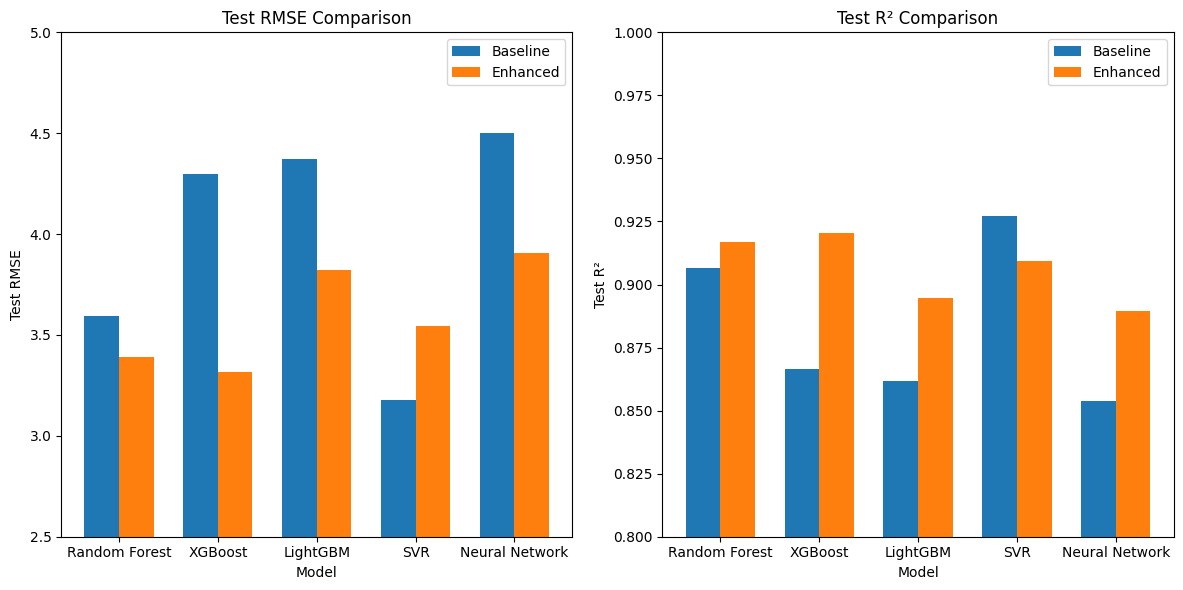

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_best_results(results_df):
    plt.figure(figsize=(12, 6))
    
    baseline_mask = results_df['ml_model'].str.contains('Baseline')
    enhanced_mask = results_df['ml_model'].str.contains('Enhanced')
    
    x = np.arange(len(results_df[baseline_mask]))
    width = 0.35
    
    # Define wiggly line coordinates
    def add_wiggly_line(ax, x_start, x_end, y_pos):
        wiggly_x = np.linspace(x_start, x_end, 100)
        wiggly_y = y_pos + 0.01 * np.sin(20 * np.pi * wiggly_x)
        ax.plot(wiggly_x, wiggly_y, color="black", linewidth=0.5)
    
    # Plot Test RMSE
    plt.subplot(1, 2, 1)
    plt.bar(x - width/2, results_df[baseline_mask]['Test RMSE'], width, label='Baseline')
    plt.bar(x + width/2, results_df[enhanced_mask]['Test RMSE'], width, label='Enhanced')
    plt.xlabel('Model')
    plt.ylabel('Test RMSE')
    plt.title('Test RMSE Comparison')
    plt.xticks(x, results_df[baseline_mask]['ml_model'].str.replace(' (Baseline)', ''))
    plt.ylim(2.5, 5)
    plt.legend()
    
    # Plot Test R²
    plt.subplot(1, 2, 2)
    plt.bar(x - width/2, results_df[baseline_mask]['Test R2'], width, label='Baseline')
    plt.bar(x + width/2, results_df[enhanced_mask]['Test R2'], width, label='Enhanced')
    plt.xlabel('Model')
    plt.ylabel('Test R²')
    plt.title('Test R² Comparison')
    plt.xticks(x, results_df[baseline_mask]['ml_model'].str.replace(' (Baseline)', ''))
    plt.ylim(0.8, 1)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Assuming `results_df` is defined, call the function:
plot_best_results(results_df)


In [8]:
results_df.to_json('results_df_training_enhanced.json', orient='records', lines=True)